<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


Space X anuncia los lanzamientos del cohete Falcon 9 en su sitio web con un costo de 62 millones de dólares; otros proveedores cuestan más de 165 millones de dólares cada uno, gran parte del ahorro se debe a que Space X puede reutilizar la primera etapa. Por lo tanto, si podemos determinar si la primera etapa aterrizará, podemos determinar el costo de un lanzamiento. Esta información se puede usar si una empresa alternativa quiere competir con Space X por un lanzamiento de cohete. En este laboratorio, crearás una pipeline de aprendizaje automático para predecir si la primera etapa aterrizará dado los datos de los laboratorios anteriores.

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)

Aquí se muestran varios ejemplos de un aterrizaje fallido:

![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


## Objectives

Realiza un Análisis de Datos exploratorio y determina las Etiquetas de Entrenamiento

* crea una columna para la clase
* Estandariza los datos
* Divide en datos de entrenamiento y datos de prueba

-Encuentra el mejor Hiperparámetro para SVM, Árboles de Clasificación y Regresión Logística

* Encuentra qué método funciona mejor usando los datos de prueba

In [110]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mis_funciones import plot_confusion_matrix

In [111]:
import importlib
import mis_funciones
mis_funciones = importlib.reload(mis_funciones)
plot_confusion_matrix = mis_funciones.plot_confusion_matrix

In [112]:
URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
data_f = pd.read_csv(URL1)
data_f.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [113]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
X = pd.read_csv(URL2)
X.head()

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


Crea un array NumPy a partir de la <code>Class</code> columna en <code>data_f</code>, aplicando el método <code>to_numpy()</code> entonces
Asignarla a la variable <code>Y</code>, asegúrate de que la salida sea una serie Pandas (solo un corchete df['nombre de la columna']).

In [114]:
# Creamos un array Numpy A partir de Class Aplicando el método to_numpy() Entonces asignarla a la variable y
y = data_f['Class'].to_numpy()

## TASK  2
Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [115]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

Dividimos los datos en datos de entrenamiento y de prueba usando la función <code>train_test_split</code>. Los datos de entrenamiento se dividen en datos de validación, un segundo conjunto usado para los datos de entrenamiento; luego, los modelos se entrenan y se seleccionan los hiperparámetros usando la función <code>GridSearchCV</code>.

In [116]:
# Dividimos los datos en entrenamiento y de prueba 
from sklearn.model_selection import train_test_split
# Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to 0.2 and random_state to 2. The training data and test data should be assigned to the following labels.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
# we can see we only have 18 test samples.
X_test.shape # shape significa la forma o dimensiones del array, en este caso el número de muestras y características del conjunto de prueba.

(18, 83)

## TASK  4

Crea un objeto de regresión logística y luego crea un objeto GridSearchCV <code>logreg_cv</code> con cv = 10. Ajusta el objeto para encontrar los mejores parámetros del diccionario <code>parameters</code>.

In [117]:
parameters = {
    'penalty': ['l1', 'l2'],
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
logreg = LogisticRegression()
logreg_cv = GridSearchCV(estimator=logreg, param_grid=parameters, cv=10)
logreg_cv.fit(X_train, y_train)

logreg_cv.best_params_


/home/miguel/mi_entorno/Python/Mysql/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/miguel/mi_entorno/Python/Mysql/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/miguel/mi_entorno/Python/Mysql/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value

{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}

In [118]:
print(" Mejores parámetros: " , logreg_cv.best_params_)
print(" Mejor Score: " , logreg_cv.best_score_)

 Mejores parámetros:  {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
 Mejor Score:  0.8339285714285714


## TASK  5
Lets look at the confusion matrix:

Accuracy:  0.8333333333333334


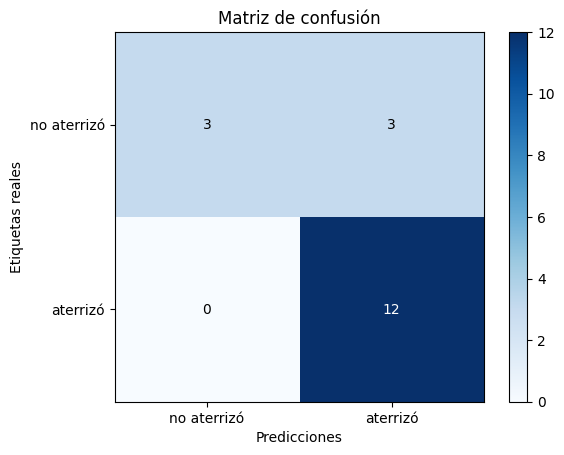

Confusion Matrix:
 [[ 3  3]
 [ 0 12]]
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



In [119]:
yhat = logreg_cv.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, yhat))
cm = plot_confusion_matrix(y_test, yhat)
print("Confusion Matrix:\n", cm)
print("Classification Report: \n", classification_report(y_test, yhat))

Al examinar la matriz de confusión, vemos que la regresión logística puede distinguir entre las diferentes clases. Vemos que el problema son los falsos positivos.

Resumen:

Verdadero Positivo - 12 (La etiqueta verdadera es 'aterrizado', la etiqueta predicha también es 'aterrizado')

Falso Positivo - 3 (La etiqueta verdadera no es 'aterrizado', pero la etiqueta predicha es 'aterrizado')

## TASK  6
Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [120]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [121]:
svm_cv = GridSearchCV( estimator= svm, cv= 10 , param_grid= parameters)
svm_cv.fit(X_train, y_train)
print("Mejores Parametros", svm_cv.best_params_)
print("Mejor Score", svm_cv.best_score_)

Mejores Parametros {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Mejor Score 0.8482142857142856


 Mejor Accuracy:  0.8333333333333334


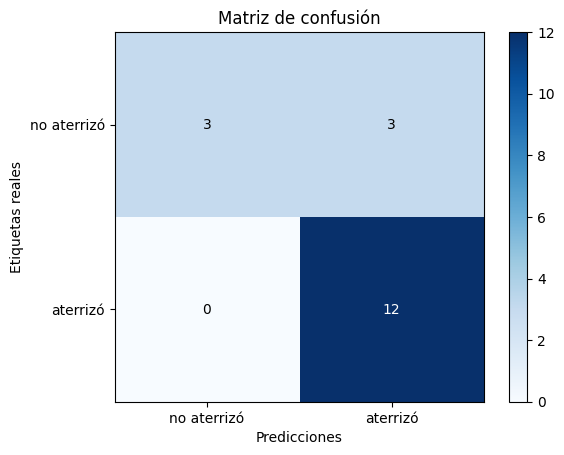

In [122]:
y_pred = svm_cv.predict(X_test)
print(" Mejor Accuracy: ", accuracy_score(y_test, y_pred))
cm = plot_confusion_matrix(y_test, y_pred)

## TASK  8
Crea un objeto clasificador de árbol de decisiones y luego crea un objeto <code>GridSearchCV</code> llamado <code>tree_cv</code> con cv = 10. Ajusta el objeto para encontrar los mejores parámetros del diccionario <code>parameters</code>. 

In [123]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(estimator=tree, param_grid=parameters, cv=10)
tree_cv.fit(X_train, y_train)

tree_cv.best_params_


/home/miguel/mi_entorno/Python/Mysql/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "/home/miguel/mi_entorno/Python/Mysql/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/miguel/mi_entorno/Python/Mysql/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1393, in wrapper
    estimator._validate_params()
  File "/home/miguel/mi_entorno/Python/Mysql/.venv/lib/python3.12/site-packages/sklearn/base.

{'criterion': 'gini',
 'max_depth': 18,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'splitter': 'best'}

In [124]:
print(f"Mejores parámetros: {tree_cv.best_params_}")
print(f"Mejor estimador: {tree_cv.best_estimator_}")
print(f"Mejor puntaje: {tree_cv.best_score_}")

Mejores parámetros: {'criterion': 'gini', 'max_depth': 18, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
Mejor estimador: DecisionTreeClassifier(max_depth=18, max_features='sqrt')
Mejor puntaje: 0.8910714285714285


Accuracy: 0.7777777777777778


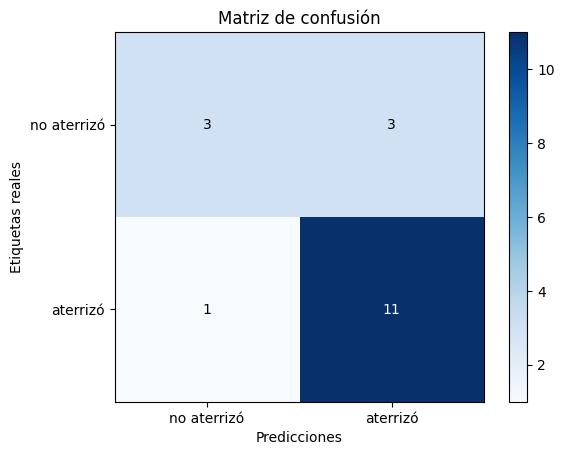

In [125]:
y_pred = tree_cv.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
cm = plot_confusion_matrix(y_test, y_pred)


## TASK  10
Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [126]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(estimator= KNN, param_grid=parameters, cv=10)
knn_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'algorithm': ['auto', 'ball_tree', ...], 'n_neighbors': [1, 2, ...], 'p': [1, 2]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosit

In [127]:
print(f"Mejores parámetros: {knn_cv.best_params_}")
print(f"Mejor estimador: {knn_cv.best_estimator_}")
print(f"Mejor puntaje: {knn_cv.best_score_}")

Mejores parámetros: {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
Mejor estimador: KNeighborsClassifier(n_neighbors=10, p=1)
Mejor puntaje: 0.8482142857142858


In [128]:
y_pred = knn_cv.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


Accuracy: 0.8333333333333334


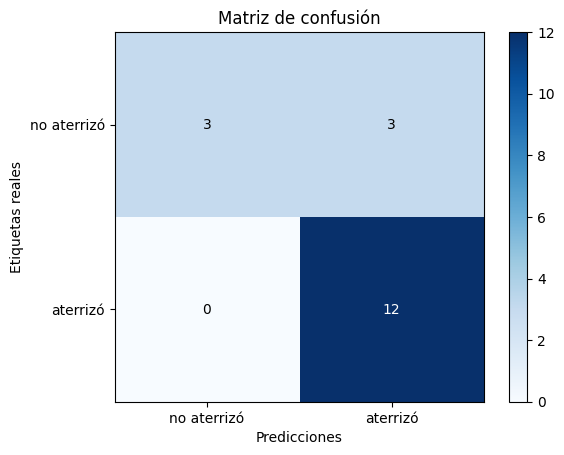

In [129]:
cm = plot_confusion_matrix(y_test, y_pred)

## Conclusión y comparación de modelos

En este proyecto probamos cuatro modelos para predecir si el lanzamiento aterriza:

- **Regresión logística:** es sencilla y fácil de interpretar. Calcula una probabilidad y decide entre las dos clases. En los datos de prueba acertó el **83,33%**.
- **SVM:** busca la mejor frontera para separar los ejemplos. Puede funcionar bien cuando la separación entre clases es compleja. Aquí acertó el **83,33%**.
- **Árbol de decisión:** toma decisiones haciendo preguntas sucesivas sobre los datos, como un diagrama de decisiones. Aquí obtuvo el mejor resultado: **88,89%**.
- **KNN:** compara cada nuevo ejemplo con los ejemplos más parecidos. En este caso acertó el **83,33%**.

### Conclusión

El modelo que recomendamos utilizar en este proyecto es el **árbol de decisión**, porque obtuvo el mayor porcentaje de aciertos en el conjunto de prueba y también el mejor resultado durante la validación cruzada. Además, sus decisiones son relativamente fáciles de explicar.

La diferencia entre los modelos no significa que uno sea siempre mejor en cualquier problema. La recomendación se basa en estos datos concretos y debería revisarse con más datos reales para confirmar que el resultado se mantiene.

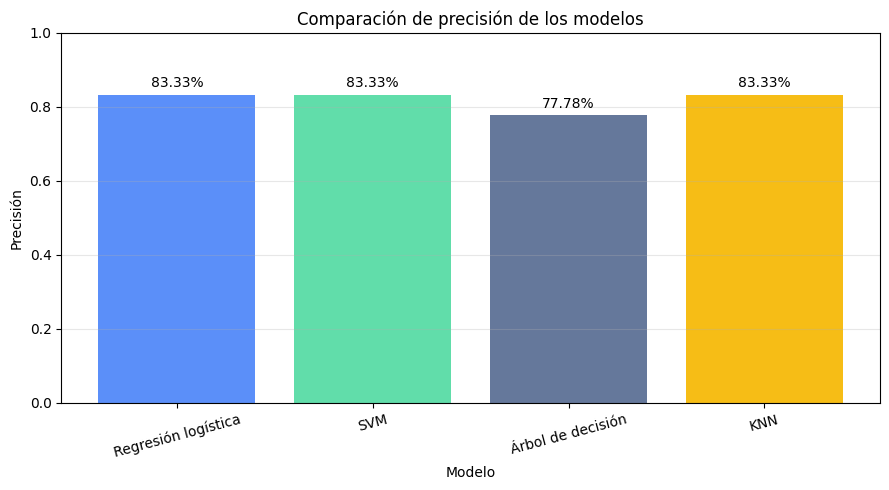

Resultados en el conjunto de prueba:
Regresión logística: 83.33%
SVM: 83.33%
Árbol de decisión: 77.78%
KNN: 83.33%


In [130]:
modelos = {
    'Regresión logística': logreg_cv,
    'SVM': svm_cv,
    'Árbol de decisión': tree_cv,
    'KNN': knn_cv
}

accuracies = {
    nombre: accuracy_score(y_test, modelo.predict(X_test))
    for nombre, modelo in modelos.items()
}

plt.figure(figsize=(9, 5))
barras = plt.bar(accuracies.keys(), accuracies.values(), color=['#5B8FF9', '#61DDAA', '#65789B', '#F6BD16'])
plt.ylim(0, 1)
plt.ylabel('Precisión')
plt.xlabel('Modelo')
plt.title('Comparación de precisión de los modelos')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)

for barra, precision in zip(barras, accuracies.values()):
    # ¿Qué es zip 
    # zip combina dos listas en pares, en este caso combina cada barra con su precisión correspondiente
    plt.text(barra.get_x() + barra.get_width() / 2, precision + 0.02,
             f'{precision:.2%}', ha='center')

plt.tight_layout()
plt.show()

print('Resultados en el conjunto de prueba:')
for nombre, precision in accuracies.items():
    print(f'{nombre}: {precision:.2%}')